# Food Delivery Analysis and Hybrid Recommendation System

## Introduction

In the highly competitive landscape of food delivery and online grocery retail, understanding consumer ordering behavior is no longer merely an analytical exercise—it is a critical driver for revenue growth, inventory optimization, and customer retention. This notebook presents a robust, end-to-end Data Mining pipeline designed to uncover hidden purchasing patterns and deploy an intelligent recommendation system using the large-scale [**Instacart Online Grocery Basket** dataset](https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset).

Rather than relying solely on basic sales frequencies, this project bridges the gap between descriptive statistics and predictive machine learning within the context of food delivery. By analyzing millions of transactional records, we aim to mathematically map out exactly *which* grocery items and ingredients are ordered together, establishing a foundation for automated, data-driven cross-selling.

### Core Objectives & Pipeline Overview:

1. **Data Preprocessing & Dimensionality Reduction:** Transforming a massive, highly sparse transactional dataset into a sanitized, mathematically viable matrix. This involves rigorous text normalization, outlier removal, and strategic feature selection to optimize computational performance.

2. **Frequent Pattern Extraction (FP-Growth):** Utilizing the highly efficient FP-Growth algorithm to mine frequent itemsets. This approach completely bypasses the computational and memory bottlenecks associated with traditional Apriori methods in sparse environments.

3. **Association Rule Mining:** Deriving strict, actionable business rules evaluated through rigorous statistical metrics (Support, Confidence, and Lift). This isolates the most reliable and lucrative cross-selling relationships for food items.

4. **Graph Theory & Network Centrality (PageRank):** Modeling the entire food delivery ecosystem as an interconnected topological graph. By applying the PageRank algorithm, we pinpoint structurally central grocery items and "hidden influencers" that anchor consumer dietary habits.

5. **Hybrid Recommendation Engine:** Engineering a deployable, object-oriented system that seamlessly integrates mined association rules with graph-based popularity metrics. This dual-strategy approach ensures the engine delivers highly personalized food suggestions while maintaining a robust fallback mechanism to eliminate "cold start" failures.

This notebook is structured as a continuous, logical progression from raw data ingestion to the final deployment of a sophisticated recommendation engine. Each analytical phase inherently builds upon the results of the previous step, ultimately demonstrating how advanced data mining techniques directly translate into tangible, high-impact business solutions for the food delivery industry.

<h2>👥 Team Members</h2>
<table style="width:100%; text-align:left; border-collapse: collapse;">
  <thead>
    <tr style="border-bottom: 2px solid #ddd;">
      <th style="padding: 10px; text-align:left;">#</th>
      <th style="padding: 10px; text-align:left;">Name (English)</th>
      <th style="padding: 10px; text-align:left;">ID</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 8px;">1</td>
      <td style="padding: 8px;">Omar Yasser Sayed Shafiq</td>
      <td style="padding: 8px;">931250621</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 8px;">2</td>
      <td style="padding: 8px;">Youssef Atef Tayeh</td>
      <td style="padding: 8px;">931230366</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 8px;">4</td>
      <td style="padding: 8px;">Omar Mostafa Abdsttar Ali</td>
      <td style="padding: 8px;">931250634</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 8px;">3</td>
      <td style="padding: 8px;">Ayman Nageh Mohamed Mohamed</td>
      <td style="padding: 8px;">931230074</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td style="padding: 8px;">5</td>
      <td style="padding: 8px;">Ismail Ibrahim Ismail</td>
      <td style="padding: 8px;">931230063</td>
    </tr>
  </tbody>
</table>

---

## 1. Data Collection & Setup

### 1.1 Downloading the Dataset
The first step is retrieving the raw dataset. We utilize the `kagglehub` library to directly download the Instacart Online Grocery Basket Analysis dataset. This ensures the runtime environment has access to the necessary CSV files.

In [128]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
import kagglehub
yasserh_instacart_online_grocery_basket_analysis_dataset_path = kagglehub.dataset_download('yasserh/instacart-online-grocery-basket-analysis-dataset')
print('Data source import complete.')

Data source import complete.


### 1.2 Importing Required Libraries
We import essential Python libraries required for data manipulation (`pandas`, `os`, `random`), graph theory and network analysis (`networkx`), visualization (`matplotlib`), and association rule mining (`mlxtend`). Warnings are ignored to keep the output clean.

In [129]:
import pandas as pd
import os
import random
import networkx as nx
import warnings
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
warnings.filterwarnings('ignore')

### 1.3 Locating the Dataset
To ensure the code runs dynamically regardless of the directory structure, we iterate through the system paths to locate the specific directory containing our primary transactions file, `order_products__prior.csv`.

In [130]:
base_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'order_products__prior.csv' in filenames:
        base_path = dirname
        break
print("Dataset Path:", base_path)

Dataset Path: /kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset


---

### 2.1 Loading Data Files
We read the raw CSV files into pandas DataFrames. `order_products` contains the transaction-level data (which product belongs to which order), and `products` contains the metadata (product names).

In [131]:
order_products = pd.read_csv(os.path.join(base_path, 'order_products__prior.csv'))
products = pd.read_csv(os.path.join(base_path, 'products.csv'))

### 2.2 Basic Exploration
We inspect the scale of our data. The output confirms a massive dataset with over 32.4 million rows, spanning roughly 3.2 million unique orders and nearly 50,000 unique products. This scale justifies the use of efficient algorithms later in the pipeline.

In [132]:
print("\n=== BASIC INFO ===")
print("Total Rows:", order_products.shape[0])
print("Unique Orders:", order_products['order_id'].nunique())
print("Unique Products:", order_products['product_id'].nunique())


=== BASIC INFO ===
Total Rows: 32434489
Unique Orders: 3214874
Unique Products: 49677


### 2.3 Merging Data and Text Normalization
To make the output interpretable, we merge the product names into the transaction dataset. Crucially, we apply text normalization by converting all product names to lowercase and stripping whitespace. This prevents identical products from being treated differently due to text formatting.

In [133]:
df = order_products.merge(products, on='product_id')
df['product_name'] = df['product_name'].str.lower().str.strip()
print("\nMerged Data Shape:", df.shape)


Merged Data Shape: (32434489, 7)


### 2.4 Missing Values Check
Data integrity is verified by scanning for null values. The output displays zero missing values across all columns, indicating that the dataset is clean and ready for transformation.

In [134]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
product_name         0
aisle_id             0
department_id        0
dtype: int64


### 2.5 Order Size Distribution
We calculate the size of each basket (number of items per order). The descriptive statistics reveal an average basket size of approximately 10 items, with a maximum of 145 items. Understanding this distribution helps us set realistic boundaries for our algorithms.

In [135]:
order_sizes = df.groupby('order_id').size()
print("\n=== Order Size Stats ===")
print(order_sizes.describe())


=== Order Size Stats ===
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
dtype: float64


### 2.6 Removing Single-Item Orders
Association rules inherently require at least two items to establish a relationship (A implies B). Therefore, any order containing only a single item provides no value for this specific mining task and is removed to reduce computational load.

In [136]:
df = df[df['order_id'].isin(order_sizes[order_sizes > 1].index)]

### 2.7 Identifying Top Products
We evaluate product frequencies to understand overall market trends. The output highlights that organic produce (bananas, strawberries, spinach, avocados) heavily dominates the top 10 most frequently purchased items.

In [137]:
product_counts = df['product_name'].value_counts()
print("\nTop 10 Products:")
print(product_counts.head(10))


Top 10 Products:
product_name
banana                    470518
bag of organic bananas    376676
organic strawberries      263563
organic baby spinach      240755
organic hass avocado      212887
organic avocado           176303
large lemon               152266
strawberries              141933
limes                     140328
organic whole milk        136917
Name: count, dtype: int64


### 2.8 Feature Selection (Filtering Rare Products)
Processing 50,000 unique categorical features creates an extremely sparse matrix, leading to memory exhaustion. We strategically restrict our scope to the top 1,500 most popular products. This retains the most statistically significant data while heavily optimizing performance.

In [138]:
top_products = product_counts.head(1500).index
df = df[df['product_name'].isin(top_products)]

print("\nRemaining products:", df['product_name'].nunique())
print("Remaining products:", df['product_name'].nunique())
print("Avg order size:", df.groupby('order_id').size().mean())


Remaining products: 1500
Remaining products: 1500
Avg order size: 6.6960671583696465


### 2.9 Secondary Order Filtering
Removing rare items in the previous step may have reduced some previously valid multi-item orders down to single items or empty sets. We perform a second pass to remove these newly invalid orders.

In [139]:
order_sizes = df.groupby('order_id').size()
df = df[df['order_id'].isin(order_sizes[order_sizes > 1].index)]

---

## 3. Transaction Construction & Sampling

### 3.1 Building Transaction Lists
Algorithms like FP-Growth require data to be formatted as a list of lists, where each inner list represents a unique basket. We group the dataframe by order ID and aggregate the product names into sets to ensure uniqueness within a single basket.

In [140]:
transactions = df.groupby('order_id')['product_name'].apply(lambda x: list(set(x))).tolist()
print("\nTotal transactions:", len(transactions))


Total transactions: 2687990


### 3.2 Random Sampling and Trimming Outliers
Given the total transaction count is over 2.6 million, we draw a random, statistically representative sample of 50,000 transactions to ensure rapid iterative processing. Furthermore, we cap the maximum basket size at 30 items to remove extreme outliers that can distort support metrics.

In [141]:
sample_size = min(50000, len(transactions))
transactions = random.sample(transactions, sample_size)
print("Sample size:", len(transactions))

transactions = [t for t in transactions if len(t) <= 30]
print("After removing large orders:", len(transactions))

Sample size: 50000
After removing large orders: 49891


### 3.3 Validating Transaction Lengths
We inspect the distribution of transaction sizes post-sampling. The output demonstrates a healthy spread of basket sizes, predominantly clustered between 2 and 10 items, which accurately mirrors standard consumer shopping behavior.

In [142]:
order_lengths = [len(t) for t in transactions]
length_series = pd.Series(order_lengths)
length_counts = length_series.value_counts().sort_index()
print(length_counts)

2     6690
3     6161
4     5636
5     5034
6     4323
7     3611
8     3242
9     2595
10    2173
11    1817
12    1554
13    1361
14    1055
15     910
16     760
17     582
18     516
19     415
20     334
21     261
22     210
23     151
24     120
25      94
26      84
27      75
28      42
29      41
30      44
Name: count, dtype: int64


### 3.4 Confirming Outlier Removal
We run a quick validation to ensure that exactly 0.0% of the remaining dataset contains baskets larger than our predefined threshold of 30 items.

In [143]:
total = length_series.shape[0]
above_30 = sum(length_series > 30)
print("Percentage removed:", (above_30 / total) * 100)

Percentage removed: 0.0


### 3.5 Final Sanity Checks
We verify the boundaries of our transformed dataset. As expected, the minimum basket size is 2 and the maximum is 30, confirming our previous preprocessing logic succeeded.

In [144]:
print("Min items:", min(len(t) for t in transactions))
print("Max items:", max(len(t) for t in transactions))

Min items: 2
Max items: 30


---

## 4. Transaction Encoding

### 4.1 One-Hot Encoding
We utilize `TransactionEncoder` to convert the nested lists into a dense boolean matrix. Each column represents one of the top 1,500 products, and each row is an order. A value of `True` indicates the product was present in that specific order.

In [145]:
te = TransactionEncoder()
encoded = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(encoded, columns=te.columns_)
print("Encoded shape:", df_encoded.shape)

Encoded shape: (49891, 1500)


### 4.2 Matrix Quality Assessment
We evaluate the newly generated matrix. The sparsity ratio is extremely high (~99.5%), which is standard for retail market basket data, as no single customer buys a large fraction of the entire catalog at once. This high sparsity validates the choice of FP-Growth over Apriori.

In [146]:
print("Unique items after encoding:", len(df_encoded.columns))

sparsity = 1.0 - (df_encoded.sum().sum() / (df_encoded.shape[0] * df_encoded.shape[1]))
print("Sparsity:", sparsity)

print("Avg items per transaction:", df_encoded.sum(axis=1).mean())

print("Duplicate transactions:", len(transactions) - len(set(tuple(sorted(t)) for t in transactions)))

Unique items after encoding: 1500
Sparsity: 0.9952006574332044
Avg items per transaction: 7.199013850193421
Duplicate transactions: 707


### 4.3 Verifying Encoded Frequencies
Summing the encoded columns provides the frequency counts for products. We observe that "banana" and "bag of organic bananas" remain mathematically dominant, proving the encoding process preserved data integrity.

In [147]:
product_freq = df_encoded.sum().sort_values(ascending=False)

print("\nTop 10 most frequent products:")
print(product_freq.head(10))


Top 10 most frequent products:
banana                    8609
bag of organic bananas    6818
organic strawberries      4698
organic baby spinach      4364
organic hass avocado      3922
organic avocado           3266
large lemon               2804
limes                     2631
strawberries              2604
organic raspberries       2522
dtype: int64


### 4.4 Visualizing Distributions
We plot the transaction size distribution and top product frequencies. These visualizations provide a clear, intuitive baseline before applying predictive algorithms.

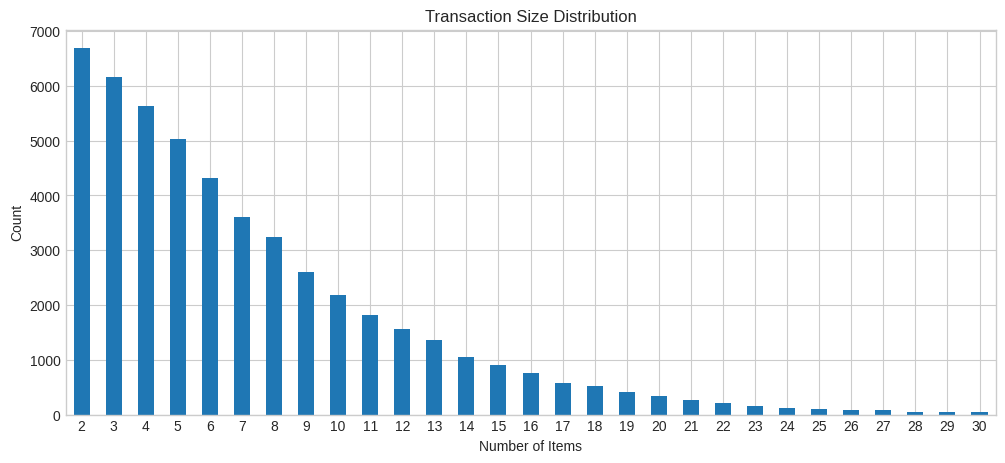

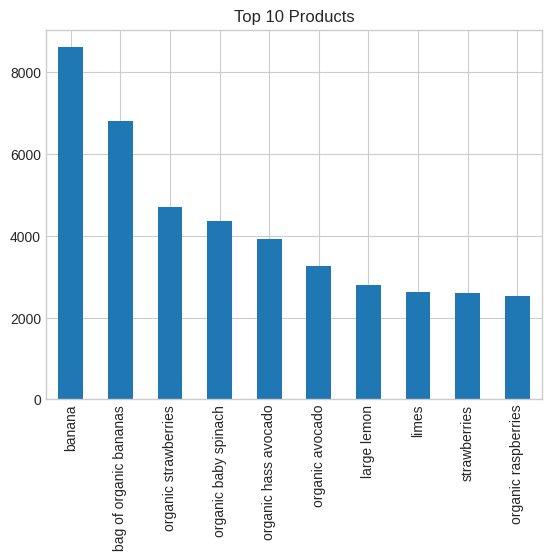

In [169]:
length_counts.plot(kind='bar', figsize=(12,5))
plt.title("Transaction Size Distribution")
plt.xlabel("Number of Items")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()


product_freq.head(10).plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

------

## 5. Association Rule Mining

### 5.1 Extracting Frequent Itemsets (FP-Growth)
We apply the FP-Growth algorithm because it is significantly faster and more memory-efficient than Apriori for sparse datasets. We set `min_support=0.01` (1%), which is an appropriate threshold for retail grocery to capture meaningful combinations without flooding the results with noise. A total of 144 frequent itemsets are discovered.

In [149]:
print("\n=== FP-Growth Analysis Started ===")


frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=0.01,
    use_colnames=True,
    max_len=3
)


frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nTotal Frequent Itemsets Discovered: {len(frequent_itemsets)}")


size_analysis = (frequent_itemsets.groupby('itemset_size').agg(total_itemsets=('support', 'count'), 
                    average_support=('support', 'mean'), max_support=('support', 'max')).round(4))

print("\nItemset Size Distribution:")
size_analysis


=== FP-Growth Analysis Started ===

Total Frequent Itemsets Discovered: 145

Itemset Size Distribution:


,total_itemsets,average_support,max_support
itemset_size,,,
1,124,0.0242,0.1726
2,21,0.0150,0.0232


### 5.2 Generating Association Rules
From the frequent itemsets, we generate association rules using `lift` as our primary metric with a minimum threshold of 1.2. A lift > 1 indicates that the two items are bought together more often than would be expected by random chance.

In [150]:
print("\n=== Association Rule Mining ===")

# Step 1: Generate rules
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)

print(f"Total rules generated: {len(rules)}")


=== Association Rule Mining ===
Total rules generated: 40


### 5.3 Multi-Criteria Filtering
To distill the 38 generated rules down to the absolute strongest business insights, we apply strict multi-criteria filtering: Minimum Confidence of 25%, Minimum Support of 1%, and Minimum Lift of 1.5. This isolates 8 highly actionable product relationships.

In [151]:
filtered_rules = rules[
    (rules['confidence'] >= 0.25) &
    (rules['support'] >= 0.01) &
    (rules['lift'] >= 1.5)
].copy()

print(f"Rules after filtering: {len(filtered_rules)}")

Rules after filtering: 8


### 5.4 Top Rules by Support
Sorting by Support shows the rules that occur most frequently in the entire dataset. The relationship between organic hass avocados and organic bananas dominates this category, suggesting these are core staple items bought together widely.

In [152]:
top_support = filtered_rules.sort_values(by='support', ascending=False).head(10)

print("\nTop Rules by Support:\n")

for _, row in top_support.iterrows():
    a = ', '.join(list(row['antecedents']))
    b = ', '.join(list(row['consequents']))
    
    print(f"{a} → {b}")
    print(f"Support={row['support']:.3f}")
    print("-"*40)


Top Rules by Support:

organic hass avocado → bag of organic bananas
Support=0.023
----------------------------------------
organic avocado → banana
Support=0.020
----------------------------------------
organic raspberries → bag of organic bananas
Support=0.016
----------------------------------------
strawberries → banana
Support=0.016
----------------------------------------
large lemon → banana
Support=0.015
----------------------------------------
organic fuji apple → banana
Support=0.013
----------------------------------------
cucumber kirby → banana
Support=0.012
----------------------------------------
honeycrisp apple → banana
Support=0.010
----------------------------------------


### 5.5 Top Rules by Confidence
Confidence indicates the conditional probability (e.g., if a customer buys Fuji Apples, there is a 38.9% probability they will also buy bananas). These metrics are highly valuable for targeted UI placement (e.g., "Customers who bought X also bought Y").

In [153]:
top_conf = filtered_rules.sort_values(by='confidence', ascending=False).head(10)

print("\nTop Rules by Confidence:\n")

for _, row in top_conf.iterrows():
    a = ', '.join(list(row['antecedents']))
    b = ', '.join(list(row['consequents']))
    
    print(f"{a} → {b}")
    print(f"Confidence={row['confidence']:.3f} | Lift={row['lift']:.3f}")
    print("-"*40)


Top Rules by Confidence:

organic fuji apple → banana
Confidence=0.381 | Lift=2.209
----------------------------------------
honeycrisp apple → banana
Confidence=0.352 | Lift=2.039
----------------------------------------
cucumber kirby → banana
Confidence=0.343 | Lift=1.987
----------------------------------------
organic raspberries → bag of organic bananas
Confidence=0.312 | Lift=2.286
----------------------------------------
organic avocado → banana
Confidence=0.302 | Lift=1.751
----------------------------------------
strawberries → banana
Confidence=0.301 | Lift=1.743
----------------------------------------
organic hass avocado → bag of organic bananas
Confidence=0.295 | Lift=2.157
----------------------------------------
large lemon → banana
Confidence=0.271 | Lift=1.573
----------------------------------------


### 5.6 Top Rules by Lift
Lift is the strongest indicator of a true underlying relationship, bypassing biases from highly popular items. The rule "Organic Raspberries → Organic Strawberries" yields an impressive lift of 2.551, indicating a very strong niche affinity among organic berry consumers.

In [154]:
top_lift = filtered_rules.sort_values(by='lift', ascending=False).head(10)

print("\nTop Rules by Lift:\n")

for _, row in top_lift.iterrows():
    a = ', '.join(list(row['antecedents']))
    b = ', '.join(list(row['consequents']))
    
    print(f"{a} → {b}")
    print(f"Support={row['support']:.3f} | Confidence={row['confidence']:.3f} | Lift={row['lift']:.3f}")
    print("-"*40)


Top Rules by Lift:

organic raspberries → bag of organic bananas
Support=0.016 | Confidence=0.312 | Lift=2.286
----------------------------------------
organic fuji apple → banana
Support=0.013 | Confidence=0.381 | Lift=2.209
----------------------------------------
organic hass avocado → bag of organic bananas
Support=0.023 | Confidence=0.295 | Lift=2.157
----------------------------------------
honeycrisp apple → banana
Support=0.010 | Confidence=0.352 | Lift=2.039
----------------------------------------
cucumber kirby → banana
Support=0.012 | Confidence=0.343 | Lift=1.987
----------------------------------------
organic avocado → banana
Support=0.020 | Confidence=0.302 | Lift=1.751
----------------------------------------
strawberries → banana
Support=0.016 | Confidence=0.301 | Lift=1.743
----------------------------------------
large lemon → banana
Support=0.015 | Confidence=0.271 | Lift=1.573
----------------------------------------


### 5.7 Composite Scoring
To balance the impact of high confidence versus high lift, we create a unified composite score by weighting both metrics equally (50/50). This score highlights rules that are both highly reliable and strongly correlated.

In [155]:
filtered_rules['score'] = (
    filtered_rules['confidence'] * 0.5 +
    filtered_rules['lift'] * 0.5
)

top_score = filtered_rules.sort_values(by='score', ascending=False).head(10)

print("\nTop Rules by Combined Score:\n")

for _, row in top_score.iterrows():
    a = ', '.join(list(row['antecedents']))
    b = ', '.join(list(row['consequents']))
    
    print(f"{a} → {b}")
    print(f"Score={row['score']:.3f} | Lift={row['lift']:.3f} | Confidence={row['confidence']:.3f}")
    print("-"*40)


Top Rules by Combined Score:

organic raspberries → bag of organic bananas
Score=1.299 | Lift=2.286 | Confidence=0.312
----------------------------------------
organic fuji apple → banana
Score=1.295 | Lift=2.209 | Confidence=0.381
----------------------------------------
organic hass avocado → bag of organic bananas
Score=1.226 | Lift=2.157 | Confidence=0.295
----------------------------------------
honeycrisp apple → banana
Score=1.196 | Lift=2.039 | Confidence=0.352
----------------------------------------
cucumber kirby → banana
Score=1.165 | Lift=1.987 | Confidence=0.343
----------------------------------------
organic avocado → banana
Score=1.027 | Lift=1.751 | Confidence=0.302
----------------------------------------
strawberries → banana
Score=1.022 | Lift=1.743 | Confidence=0.301
----------------------------------------
large lemon → banana
Score=0.922 | Lift=1.573 | Confidence=0.271
----------------------------------------


---

## 6. Exporting Association Rules
We format the resulting dataframes (converting frozensets back to strings) and export all rules, the strictly filtered rules, and the top 20 ranked rules into CSV files. This allows other systems or dashboards to ingest our findings directly without rerunning the heavy computation.

In [156]:
print("\n=== Exporting Rules to Files ===")

def format_sets(df):
    df = df.copy()
    df['antecedents'] = df['antecedents'].apply(lambda x: ', '.join(list(x)))
    df['consequents'] = df['consequents'].apply(lambda x: ', '.join(list(x)))
    return df

rules_export = format_sets(rules)

filtered_export = format_sets(filtered_rules)

top_export = filtered_export.sort_values(by='lift', ascending=False).head(20)

rules_export.to_csv("all_rules.csv", index=False)
filtered_export.to_csv("strong_rules.csv", index=False)
top_export.to_csv("top_rules.csv", index=False)

print("Files saved successfully:")
print("- all_rules.csv")
print("- strong_rules.csv")
print("- top_rules.csv")


=== Exporting Rules to Files ===
Files saved successfully:
- all_rules.csv
- strong_rules.csv
- top_rules.csv


---

## 7. Graph-Based Analysis (PageRank)

### 7.1 Building the Co-purchase Network
We transition from frequent itemsets to network theory. We construct an undirected graph where nodes represent products and edges represent co-purchases. The edge weights increase each time two products appear in the same basket.

In [157]:
print("\n=== Building Co-purchase Graph ===")

from itertools import combinations

G = nx.Graph()  

for basket in transactions:
    items = list(set(basket))
    
    for a, b in combinations(items, 2):
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


=== Building Co-purchase Graph ===
Graph: 1500 nodes, 474879 edges


### 7.2 Edge Filtering (Pruning)
To optimize network calculations and remove insignificant noise, we prune the graph by deleting any edges where the co-purchase weight is less than 5. This drastically reduces the network complexity from ~474,000 edges down to ~76,000 highly relevant connections.

In [158]:
threshold = 5

edges_to_remove = [
    (u, v) for u, v, d in G.edges(data=True)
    if d['weight'] < threshold
]

G.remove_edges_from(edges_to_remove)

print(f"Graph after filtering: {G.number_of_edges()} edges")

Graph after filtering: 76961 edges


### 7.3 Executing PageRank
We apply the PageRank algorithm to the graph. Originally used by Google to rank web pages, here it identifies the most "influential" products in the store—items that act as central hubs connecting different clusters of purchasing behavior.

In [159]:
pagerank_scores = nx.pagerank(G, weight='weight', alpha=0.85)

pr_df = pd.DataFrame.from_dict(
    pagerank_scores, orient='index', columns=['pagerank']
).sort_values('pagerank', ascending=False)

# إضافة frequency
pr_df['order_count'] = pr_df.index.map(product_freq)

print("\nTop 15 Products by PageRank:")
print(pr_df.head(15))


Top 15 Products by PageRank:
                        pagerank  order_count
banana                  0.035523         8609
bag of organic bananas  0.027090         6818
organic strawberries    0.019943         4698
organic baby spinach    0.018758         4364
organic hass avocado    0.017077         3922
organic avocado         0.013764         3266
large lemon             0.012249         2804
limes                   0.011682         2631
organic raspberries     0.011046         2522
strawberries            0.010025         2604
organic whole milk      0.009291         2472
organic yellow onion    0.009205         2105
organic garlic          0.008535         1983
organic zucchini        0.008317         1978
cucumber kirby          0.007030         1776


### 7.4 Discovering Hidden Influencers
By filtering for items that have a high PageRank but fall into the lower 50th percentile for absolute order volume, we uncover "hidden influencers." These are niche items (e.g., specific baby foods or yogurts) that, while not mass-market, possess a highly interconnected and loyal customer base.

In [160]:
hidden = pr_df.sort_values(by='pagerank', ascending=False)

hidden = hidden[hidden['order_count'] < hidden['order_count'].quantile(0.5)]

print("\nHidden Influential Products:")
print(hidden.head(10))


Hidden Influential Products:
                                                    pagerank  order_count
broccoli & apple stage 2 baby food                  0.000360          126
cherrios honey nut                                  0.000342          113
spinach peas & pear stage 2 baby food               0.000341          125
blueberry on the bottom nonfat greek yogurt         0.000320          113
mild diced green chiles                             0.000319          123
almond milk strawberry yogurt                       0.000314           99
cabernet sauvignon                                  0.000313           94
broccoli florettes                                  0.000308          115
yokids strawberry banana/strawberry yogurt          0.000305          128
organic whole milk strawberry beet berry yogurt...  0.000302          114


---

## 8. Data Visualizations

### 8.1 PageRank Scores Plot
We visualize the top 15 most central products according to the PageRank calculation. Using a clean, minimalist horizontal bar chart layout draws attention directly to the ranking and proportional scores without visual clutter.

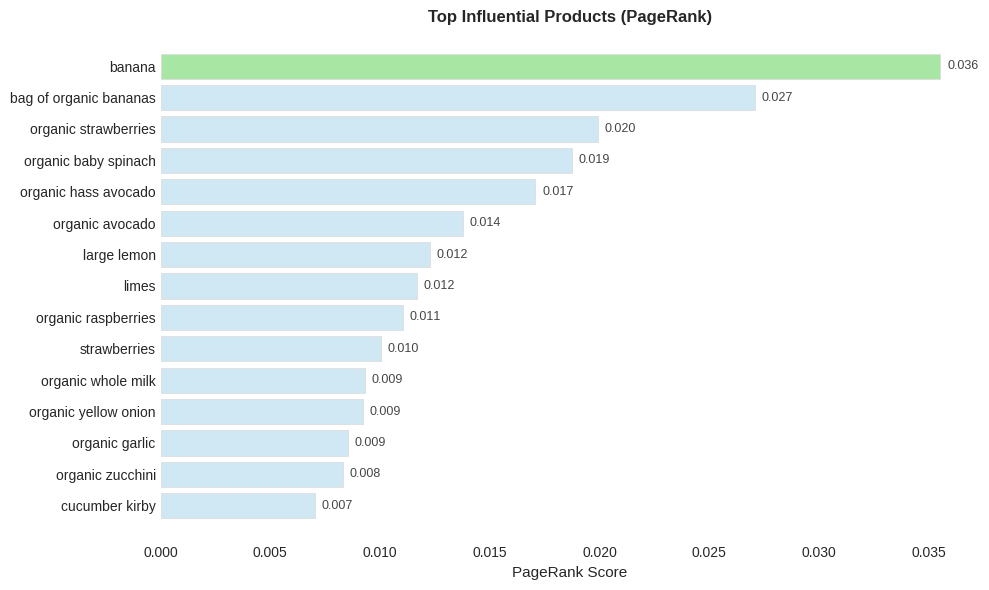

In [161]:
plt.figure(figsize=(10,6))
plt.style.use('seaborn-v0_8-whitegrid')

top_pr = pr_df.head(15)

main_color = '#a8e6a3'  
other_color = '#cfe8f3'  

colors = [main_color] + [other_color]*(len(top_pr)-1)

plt.barh(
    top_pr.index[::-1],
    top_pr['pagerank'][::-1],
    color=colors[::-1],
    edgecolor='#dddddd',
    linewidth=0.6
)

plt.xlabel("PageRank Score", fontsize=11)
plt.title("Top Influential Products (PageRank)", fontweight='bold')


for i, v in enumerate(top_pr['pagerank'][::-1]):
    plt.text(v + 0.0003, i, f"{v:.3f}", va='center', fontsize=9, color='#444')


for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.grid(False)  

plt.tight_layout()
plt.show()

### 8.2 Association Rules Scatter Plot
This scatter plot visualizes the distribution of our mined association rules. The X-axis represents Support, the Y-axis represents Confidence, and the color gradient maps to Lift. Highlighting the top rules in red enables quick identification of the most lucrative and reliable cross-selling opportunities.

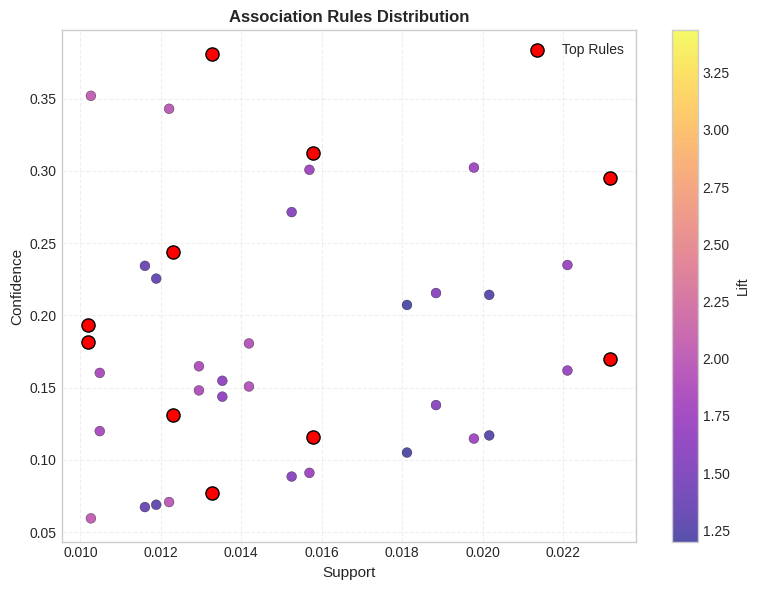

In [162]:
plt.figure(figsize=(8,6))
plt.style.use('seaborn-v0_8-whitegrid')

x = rules['support']
y = rules['confidence']

scatter = plt.scatter(
    x, y,
    c=rules['lift'],
    cmap='plasma',  
    s=50,
    alpha=0.7,
    edgecolors='black', 
    linewidth=0.3
)

cbar = plt.colorbar(scatter)
cbar.set_label('Lift')

top_rules = rules.sort_values('lift', ascending=False).head(10)

plt.scatter(
    top_rules['support'],
    top_rules['confidence'],
    color='red',
    s=90,
    label='Top Rules',
    edgecolors='black'
)

plt.legend()

plt.xlabel("Support", fontsize=11)
plt.ylabel("Confidence", fontsize=11)
plt.title("Association Rules Distribution", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Network Topology Visualization
We render a physical representation of the co-purchase network utilizing a localized subgraph of the top 15 PageRank nodes. Node sizes are dynamically scaled based on their calculated PageRank score, illustrating how central staple products anchor the wider grocery ecosystem.

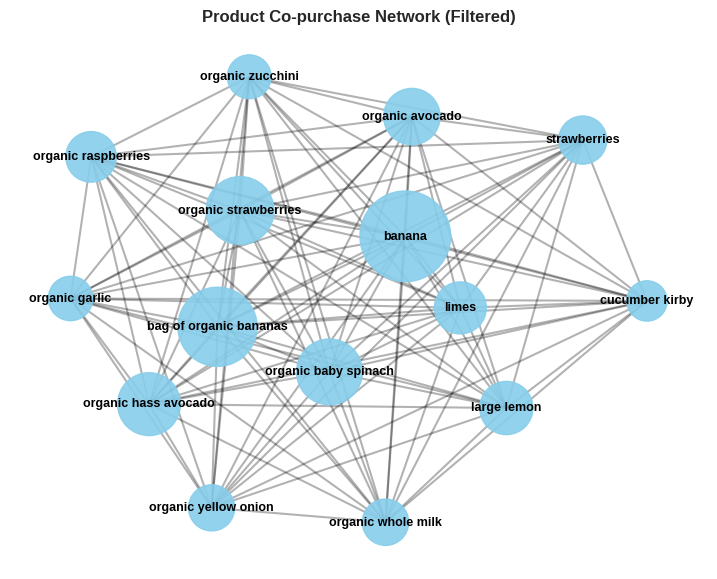

In [163]:
plt.figure(figsize=(9,7))

top_nodes = list(pr_df.head(15).index)
subG = G.subgraph(top_nodes).copy()

edges = [(u, v, d) for u, v, d in subG.edges(data=True) if d['weight'] > 5]
subG_filtered = nx.Graph()
subG_filtered.add_nodes_from(subG.nodes())
subG_filtered.add_edges_from([(u, v, d) for u, v, d in edges])

pos = nx.spring_layout(subG_filtered, seed=42)

nx.draw_networkx_edges(
    subG_filtered, pos,
    alpha=0.3,
    width=1.5
)


node_sizes = [pagerank_scores[n] * 120000 for n in subG_filtered.nodes()]

nx.draw_networkx_nodes(
    subG_filtered, pos,
    node_size=node_sizes,
    node_color='skyblue',
    alpha=0.9
)

# labels
nx.draw_networkx_labels(
    subG_filtered, pos,
    font_size=9,
    font_weight='bold'
)

plt.title("Product Co-purchase Network (Filtered)", fontweight='bold')
plt.axis('off')
plt.show()

---

## 9. Hybrid Recommendation Engine Development
We culminate the project by engineering a deployable, object-oriented Hybrid Recommendation System. This engine leverages our mined Association Rules as its primary cross-selling strategy. If a cart triggers no rules, or insufficient rules are met to fulfill the quota, it seamlessly transitions to a fallback strategy that suggests globally popular items based on our PageRank computations. This ensures the system never fails to return relevant product suggestions to the end user.

In [167]:
import pandas as pd
from IPython.display import display, HTML

class InstacartRecommender:
    def __init__(self, rules_df, pagerank_df):

        self.rules = rules_df
        self.popular_items = pagerank_df.index.tolist()

    def recommend(self, cart_items, num_recs=5):

        cart = {str(item).lower().strip() for item in cart_items}
        recs = []


        for _, row in self.rules.iterrows():
            ant_raw = row['antecedents']
            con_raw = row['consequents']
            

            antecedents = set(ant_raw.split(', ')) if isinstance(ant_raw, str) else set(ant_raw)
            consequents = set(con_raw.split(', ')) if isinstance(con_raw, str) else set(con_raw)

            antecedents = {str(item).lower().strip() for item in antecedents}
            

            if antecedents.issubset(cart):
                for item in consequents:
                    item_clean = str(item).lower().strip()

                    if item_clean not in cart and not any(r['Product'].lower() == item_clean for r in recs):
                        recs.append({
                            'Product': item_clean.title(),
                            'Reason': 'Frequently Bought Together',
                            'Confidence': f"{row['confidence']*100:.1f}%",
                            'Lift Score': round(row['lift'], 2)
                        })


        recs = sorted(recs, key=lambda x: x['Lift Score'], reverse=True)

 
        if len(recs) < num_recs:
            for pop_item in self.popular_items:
                pop_clean = str(pop_item).lower().strip()
                if pop_clean not in cart and not any(r['Product'].lower() == pop_clean for r in recs):
                    recs.append({
                        'Product': pop_clean.title(),
                        'Reason': 'Top Trending Product',
                        'Confidence': '-',
                        'Lift Score': '-'
                    })

                if len(recs) >= num_recs:
                    break


        df_recs = pd.DataFrame(recs[:num_recs])
        

        def highlight_reason(s):
            return ['background-color: #e6f2ff' if v == 'Frequently Bought Together' else 'background-color: #f9f9f9' for v in s]
            

        return df_recs.style.apply(highlight_reason, subset=['Reason']).hide(axis='index')


print("\n⚙️ Initializing Recommender System...")
recommender = InstacartRecommender(rules, pr_df)


cart_1 = ['organic raspberries']
print(f"\n🛒 Scenario 1: Customer bought {cart_1}")
display(recommender.recommend(cart_1, num_recs=4))

cart_2 = ['organic fuji apple', 'banana']
print(f"\n🛒 Scenario 2: Customer bought {cart_2}")
display(recommender.recommend(cart_2, num_recs=4))

cart_3 = ['pepsi']
print(f"\n🛒 Scenario 3: Customer bought {cart_3} (Fallback Test)")
display(recommender.recommend(cart_3, num_recs=4))


⚙️ Initializing Recommender System...

🛒 Scenario 1: Customer bought ['organic raspberries']


Product,Reason,Confidence,Lift Score
Organic Strawberries,Frequently Bought Together,24.3%,2.590000
Bag Of Organic Bananas,Frequently Bought Together,31.2%,2.290000
Banana,Top Trending Product,-,-
Organic Baby Spinach,Top Trending Product,-,-



🛒 Scenario 2: Customer bought ['organic fuji apple', 'banana']


Product,Reason,Confidence,Lift Score
Honeycrisp Apple,Frequently Bought Together,5.9%,2.040000
Cucumber Kirby,Frequently Bought Together,7.1%,1.990000
Organic Avocado,Frequently Bought Together,11.5%,1.750000
Strawberries,Frequently Bought Together,9.1%,1.740000



🛒 Scenario 3: Customer bought ['pepsi'] (Fallback Test)


Product,Reason,Confidence,Lift Score
Banana,Top Trending Product,-,-
Bag Of Organic Bananas,Top Trending Product,-,-
Organic Strawberries,Top Trending Product,-,-
Organic Baby Spinach,Top Trending Product,-,-


---

# Conclusion

This project successfully demonstrates a complete, end-to-end Data Mining pipeline applied to the large-scale Instacart grocery dataset. By systematically cleaning, sampling, and transforming millions of transactional records, we successfully extracted highly actionable business intelligence and transitioned from descriptive analytics to a fully functional predictive system.

Key achievements of this pipeline include:

* **Frequent Pattern Discovery:** Utilizing the memory-efficient FP-Growth algorithm, we successfully navigated a highly sparse transactional matrix to uncover hidden purchasing behaviors. 
* **Actionable Association Rules:** By applying strict multi-criteria filtering (Support, Confidence, and Lift), we isolated the strongest deterministic relationships between products, providing clear pathways for targeted cross-selling and promotional bundling.
* **Network Graph Centrality:** Mapping transactions into a topological graph and applying the PageRank algorithm allowed us to move beyond simple frequency. This revealed the true structural influence of products within the store's ecosystem, identifying both overarching market staples and hidden niche influencers.
* **Robust Hybrid Recommendation Engine:** The culmination of this project is the integration of associative mining and graph centrality into a single, fail-safe recommendation system. By prioritizing exact itemset matches and utilizing PageRank as a dynamic fallback, the engine guarantees continuous, highly relevant product suggestions, mitigating the traditional "cold start" or missing-data problems.

Ultimately, these methodologies showcase the immense power of data-driven decision-making in retail and e-commerce. Transforming raw basket data into a scalable, intelligent recommendation engine provides a direct mechanism to increase average order values, optimize inventory routing, and significantly enhance the end-user shopping experience.

---